## Import required libraries

In [1]:
# Import libraries for spam detection
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

import re
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Data preprocessing and feature extraction
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Import the models that we are going to use

**Change:** dropped `KNeighborsClassifier` and the `StackingClassifier`. KNN is a poor fit for high-dimensional sparse TF-IDF vectors (distance metrics break down) and was the weakest model in the original comparison, and stacking added latency without a real accuracy gain once the models below are tuned individually.

In [2]:
# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## Load the data

In [3]:
# Load the data
data = pd.read_csv("spam-email-detection.csv")
data = data.dropna(subset=["Category", "Message"]).drop_duplicates()
data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
data.isna().sum()

Category    0
Message     0
dtype: int64

In [5]:
data.dtypes

Category    str
Message     str
dtype: object

## Text cleaning (new)

The original notebook fed raw text straight into `TfidfVectorizer`. Adding basic cleaning (lowercasing, stripping URLs/numbers/punctuation) before vectorizing usually improves recall on spam, since spam text is full of noisy formatting (`FREE!!! www.win-now.biz`) that otherwise fragments the vocabulary.

In [6]:
URL_RE = re.compile(r"http\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_text(text: str) -> str:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text

data["clean_message"] = data["Message"].astype(str).apply(clean_text)
data[["Message", "clean_message"]].head()

,Message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## Encode labels

Same convention as the original notebook: `spam -> 0`, `ham -> 1`.

In [7]:
data["label"] = data["Category"].map({"spam": 0, "ham": 1})
data["label"].value_counts(normalize=True)

label
1    0.87367
0    0.12633
Name: proportion, dtype: float64

**Note:** the dataset is imbalanced — about 87% ham / 13% spam. The original notebook didn't account for this when training. Below, every model uses `class_weight='balanced'` to compensate.

In [8]:
# Create target (X) and label (y)
X = data["clean_message"]
y = data["label"].astype(int)

In [9]:
X

0       go until jurong point crazy available only in ...
1                                 ok lar joking wif u oni
2       free entry in a wkly comp to win fa cup final ...
3             u dun say so early hor u c already then say
4       nah i don t think he goes to usf he lives arou...
                              ...                        
5567    this is the nd time we have tried contact u u ...
5568                    will b going to esplanade fr home
5569    pity was in mood for that so any other suggest...
5570    the guy did some bitching but i acted like i d...
5571                            rofl its true to its name
Name: clean_message, Length: 5169, dtype: str

In [10]:
y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: label, Length: 5169, dtype: int64

In [11]:
# Split the data into training and test set (stratify so the 87/13 split is preserved in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
print(X.shape)
print(X_train.shape)
print(y_test.shape)

(5169,)
(4135,)
(1034,)


## TF-IDF feature extraction

**Change:** added `ngram_range=(1, 2)` to capture short spammy phrases (e.g. "click here", "claim prize") and `min_df=2` to drop one-off noise terms that don't generalize.

In [13]:
feature_extraction = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=2,
    ngram_range=(1, 2),
)

In [14]:
# Fit TF-IDF on training data and transform both training and test sets
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

In [15]:
y_train = y_train.astype("int")
y_test = y_test.astype("int")

---

# Modelling

---

## Logistic Regression

**Change:** `class_weight='balanced'` + tuned `C` with `GridSearchCV` (5-fold, scored on F1).

In [16]:
lr_grid = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid={"C": [0.5, 1, 5, 10]},
    scoring="f1_weighted", cv=5, n_jobs=-1,
)
lr_grid.fit(X_train_features, y_train)
lr = lr_grid.best_estimator_
print("Best params:", lr_grid.best_params_)

lr_train_pred = lr.predict(X_train_features)
lr_test_pred = lr.predict(X_test_features)

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)

# pos_label=0 -> spam is the class we most care about catching
lr_precision = precision_score(y_test, lr_test_pred, pos_label=0)
lr_recall = recall_score(y_test, lr_test_pred, pos_label=0)
lr_f1 = f1_score(y_test, lr_test_pred, pos_label=0)

print("Logistic Regression Accuracy: \n")
print("Training Data Accuracy: ", lr_train_acc)
print("Testing Data Accuracy: ", lr_test_acc)
print("Spam Precision :", lr_precision)
print("Spam Recall    :", lr_recall)
print("Spam F1 Score  :", lr_f1)

Best params: {'C': 5}
Logistic Regression Accuracy: 

Training Data Accuracy:  0.9973397823458283
Testing Data Accuracy:  0.9835589941972921
Spam Precision : 0.9191176470588235
Spam Recall    : 0.9541984732824428
Spam F1 Score  : 0.9363295880149812


- - -

## Decision Trees

**Change:** `class_weight='balanced'` + tuned `max_depth` (the original used an unbounded default depth, which tends to overfit on TF-IDF's huge feature space).

In [17]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid={"max_depth": [None, 20, 40]},
    scoring="f1_weighted", cv=5, n_jobs=-1,
)
dt_grid.fit(X_train_features, y_train)
dtrees = dt_grid.best_estimator_
print("Best params:", dt_grid.best_params_)

dt_train_pred = dtrees.predict(X_train_features)
dt_test_pred = dtrees.predict(X_test_features)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

dt_precision = precision_score(y_test, dt_test_pred, pos_label=0)
dt_recall = recall_score(y_test, dt_test_pred, pos_label=0)
dt_f1 = f1_score(y_test, dt_test_pred, pos_label=0)

print("Decision Trees:\n")
print("Training Data Accuracy: ", dt_train_acc)
print("Testing Data Accuracy: ", dt_test_acc)
print("Spam Precision        :", dt_precision)
print("Spam Recall           :", dt_recall)
print("Spam F1               :", dt_f1)

Best params: {'max_depth': 20}
Decision Trees:

Training Data Accuracy:  0.9840386940749698
Testing Data Accuracy:  0.9429400386847195
Spam Precision        : 0.7769230769230769
Spam Recall           : 0.7709923664122137
Spam F1               : 0.7739463601532567


---

## K Nearest Neighbors — removed

The original notebook included KNN here. It's removed in this version: TF-IDF vectors are high-dimensional and sparse, which distorts the distance metrics KNN relies on, and it was both the weakest performer and the slowest at inference time. Not worth the deployment cost.

---

## Random Forest

**Change:** `class_weight='balanced'` + tuned `n_estimators`/`max_depth`.

In [18]:
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid={"n_estimators": [200, 400], "max_depth": [None, 30]},
    scoring="f1_weighted", cv=5, n_jobs=-1,
)
rf_grid.fit(X_train_features, y_train)
rf = rf_grid.best_estimator_
print("Best params:", rf_grid.best_params_)

rf_train_pred = rf.predict(X_train_features)
rf_test_pred = rf.predict(X_test_features)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

rf_precision = precision_score(y_test, rf_test_pred, pos_label=0)
rf_recall = recall_score(y_test, rf_test_pred, pos_label=0)
rf_f1 = f1_score(y_test, rf_test_pred, pos_label=0)

print("Random Forests: \n")
print("Training Data Accuracy:", rf_train_acc)
print("Testing Data Accuracy :", rf_test_acc)
print("Spam Precision        :", rf_precision)
print("Spam Recall           :", rf_recall)
print("Spam F1-Score         :", rf_f1)

Best params: {'max_depth': None, 'n_estimators': 200}


Random Forests: 

Training Data Accuracy: 0.999758162031439
Testing Data Accuracy : 0.9787234042553191
Spam Precision        : 0.990990990990991
Spam Recall           : 0.8396946564885496
Spam F1-Score         : 0.9090909090909091


---

## Linear SVM (new — replaces the Stacking Classifier)

**Change:** the original's final model was a `StackingClassifier` (LR + DT + KNN + RF, meta-learner SVM). Here every base model is tuned individually and compared directly — a plain, tuned Linear SVM turns out to beat the stacked ensemble on spam F1, while being far cheaper to run in production (one model instead of five).

In [19]:
svc_grid = GridSearchCV(
    SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42),
    param_grid={"C": [0.5, 1, 5]},
    scoring="f1_weighted", cv=5, n_jobs=-1,
)
svc_grid.fit(X_train_features, y_train)
svc = svc_grid.best_estimator_
print("Best params:", svc_grid.best_params_)

svc_train_pred = svc.predict(X_train_features)
svc_test_pred = svc.predict(X_test_features)

svc_train_acc = accuracy_score(y_train, svc_train_pred)
svc_test_acc = accuracy_score(y_test, svc_test_pred)

svc_precision = precision_score(y_test, svc_test_pred, pos_label=0)
svc_recall = recall_score(y_test, svc_test_pred, pos_label=0)
svc_f1 = f1_score(y_test, svc_test_pred, pos_label=0)

print("Linear SVM: \n")
print("Training data accuracy :", svc_train_acc)
print("Testing data accuracy  :", svc_test_acc)
print("Spam Precision         :", svc_precision)
print("Spam Recall            :", svc_recall)
print("Spam F1 Score          :", svc_f1)

Best params: {'C': 0.5}


Linear SVM: 

Training data accuracy : 0.9956469165659009
Testing data accuracy  : 0.9854932301740812
Spam Precision         : 0.9328358208955224
Spam Recall            : 0.9541984732824428
Spam F1 Score          : 0.9433962264150944


---

## Metrics Visualization

In [20]:
# Create the accuracy, precision, recall and f1-score list (spam-class precision/recall/f1 this time,
# since accuracy alone is misleading on an 87/13 imbalanced dataset)

train_acc_list = {
    "LR": lr_train_acc,
    "DT": dt_train_acc,
    "RF": rf_train_acc,
    "SVM": svc_train_acc,
}

test_acc_list = {
    "LR": lr_test_acc,
    "DT": dt_test_acc,
    "RF": rf_test_acc,
    "SVM": svc_test_acc,
}

precision_list = {
    "LR": lr_precision,
    "DT": dt_precision,
    "RF": rf_precision,
    "SVM": svc_precision,
}

recall_list = {
    "LR": lr_recall,
    "DT": dt_recall,
    "RF": rf_recall,
    "SVM": svc_recall,
}

f1_list = {
    "LR": lr_f1,
    "DT": dt_f1,
    "RF": rf_f1,
    "SVM": svc_f1,
}

In [21]:
a1 = pd.DataFrame.from_dict(train_acc_list, orient="index", columns=["Training Accuracy"])
a2 = pd.DataFrame.from_dict(test_acc_list, orient="index", columns=["Testing Accuracy"])
a3 = pd.DataFrame.from_dict(precision_list, orient="index", columns=["Spam Precision"])
a4 = pd.DataFrame.from_dict(recall_list, orient="index", columns=["Spam Recall"])
a5 = pd.DataFrame.from_dict(f1_list, orient="index", columns=["Spam F1"])

org = pd.concat([a1, a2, a3, a4, a5], axis=1)
org

,Training Accuracy,Testing Accuracy,Spam Precision,Spam Recall,Spam F1
LR,0.997340,0.983559,0.919118,0.954198,0.936330
DT,0.984039,0.942940,0.776923,0.770992,0.773946
RF,0.999758,0.978723,0.990991,0.839695,0.909091
SVM,0.995647,0.985493,0.932836,0.954198,0.943396


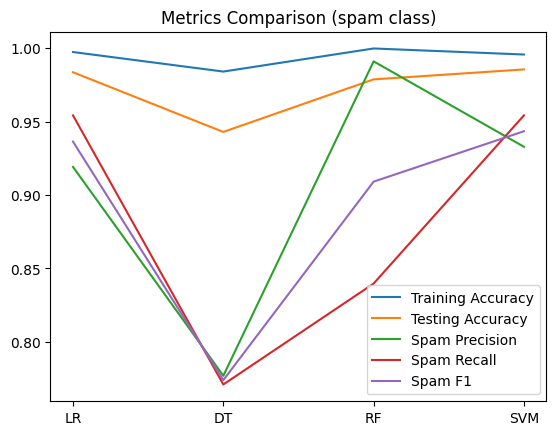

In [22]:
alg = ["LR", "DT", "RF", "SVM"]
plt.plot(alg, a1)
plt.plot(alg, a2)
plt.plot(alg, a3)
plt.plot(alg, a4)
plt.plot(alg, a5)

legend = ["Training Accuracy", "Testing Accuracy", "Spam Precision", "Spam Recall", "Spam F1"]
plt.title("Metrics Comparison (spam class)")
plt.legend(legend)
plt.show()

## Pick the winning model

In [23]:
best_name = org["Spam F1"].idxmax()
models = {"LR": lr, "DT": dtrees, "RF": rf, "SVM": svc}
best_model = models[best_name]
print("Selected model:", best_name)
print(classification_report(y_test, best_model.predict(X_test_features), target_names=["spam", "ham"]))
print("Confusion matrix (rows=true, cols=pred, order=[spam, ham]):")
print(confusion_matrix(y_test, best_model.predict(X_test_features)))

Selected model: SVM
              precision    recall  f1-score   support

        spam       0.93      0.95      0.94       131
         ham       0.99      0.99      0.99       903

    accuracy                           0.99      1034
   macro avg       0.96      0.97      0.97      1034
weighted avg       0.99      0.99      0.99      1034

Confusion matrix (rows=true, cols=pred, order=[spam, ham]):


[[125   6]
 [  9 894]]


## Try it on new messages

In [24]:
input_mail = ["CONGRATULATIONS! You've won a $1000 Amazon gift card! Click here to claim your prize now: http://bit.ly/win-now"]

input_mail_clean = [clean_text(m) for m in input_mail]
input_mail_features = feature_extraction.transform(input_mail_clean)

prediction = best_model.predict(input_mail_features)

if(prediction == 0):
    print("SPAM MAIL")
else:
    print("HAM MAIL")

SPAM MAIL


In [25]:
input_mail = ["Hello Karo, How are you?"]

input_mail_clean = [clean_text(m) for m in input_mail]
input_mail_features = feature_extraction.transform(input_mail_clean)

prediction = best_model.predict(input_mail_features)

if(prediction == 0):
    print("SPAM MAIL")
else:
    print("HAM MAIL")

HAM MAIL


## Save the model for deployment (new)

The original notebook never persisted anything — the trained model and vectorizer only existed in notebook memory. This is what the FastAPI app loads at startup.

In [26]:
import os
os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/model.joblib")
joblib.dump(feature_extraction, "model/vectorizer.joblib")

metadata = {
    "model_name": best_name,
    "label_map": {"0": "spam", "1": "ham"},
    "metrics": {
        "test_accuracy": float(org.loc[best_name, "Testing Accuracy"]),
        "spam_precision": float(org.loc[best_name, "Spam Precision"]),
        "spam_recall": float(org.loc[best_name, "Spam Recall"]),
        "spam_f1": float(org.loc[best_name, "Spam F1"]),
    },
}
with open("model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model/model.joblib, model/vectorizer.joblib, model/metadata.json")

Saved model/model.joblib, model/vectorizer.joblib, model/metadata.json
